# 05a — Time Series Components: Level, Trend, Seasonality & Noise

## Why this notebook exists

> **Before choosing a forecasting model, we need to understand what patterns exist in the demand series.**

Every model on our ladder — Naive, Seasonal Naive, Moving Average, Exponential Smoothing, ARIMA, LSTM, LLM — makes different assumptions about **what structure** is present in the data. This notebook is the **foundation chapter** that makes those assumptions visible *before* we ask any model to forecast.

*It is not a benchmark. It is a lens.*

| Notebook | Role |
|---|---|
| **05a (this)** | **Understand the components** — what could be in the data |
| **05b** | **Measure the baselines** — what the simplest models actually achieve |
| **06 onward** | **Test the ladder** — do more complex models help, and where? |

**How to read this notebook:** `Intuition → Visual example → Mathematics → Real data → Insight`. Every chart answers a question; no decorative graphics.

**Frozen experiment reminder:** This notebook does **not** change the frozen design: M5 = 500 stratified series, Store Item Demand = 500 series (all), common window 2013-01-01 → 2016-05-22, horizon 28 days, 8 rolling origins, metrics MAE/RMSE/sMAPE/WAPE, seed 42. It only *explains* the components those models will later try to capture.

## 0. Environment

Standardise paths, style, colours. No model fitting here — only explanation and illustration.

In [1]:
import sys, pathlib, json, warnings
warnings.filterwarnings("ignore")
sys.path.insert(0, str(pathlib.Path(".").resolve()))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
try:
    get_ipython().run_line_magic("matplotlib", "inline")
except:
    pass
from pathlib import Path

# Robust project root
for _cand in [Path(".").resolve(), Path("..").resolve(), Path.cwd(), Path.cwd().parent]:
    if (_cand / "02_data").exists():
        PROJ = _cand
        break
else:
    PROJ = Path("..").resolve()
sys.path.insert(0, str(PROJ / "11_src"))
from plotting import apply_style
apply_style()

FIG_DIR = PROJ / "07_figures/model_explanations/time_series_components"
FIG_DIR.mkdir(parents=True, exist_ok=True)

SEED = 42
rng = np.random.default_rng(SEED)
print(f"Project root: {PROJ}")
print(f"Figures will be saved to: {FIG_DIR}")

Project root: D:\Brain\07_Research\AI-INVENTORY-OPTIMIZATION
Figures will be saved to: D:\Brain\07_Research\AI-INVENTORY-OPTIMIZATION\07_figures\model_explanations\time_series_components


---

# 1. What Is a Time Series?

## 1.1 Plain-English definition

A **time series** is a sequence of observations indexed by time. Order matters.

| Date | Demand (units) |
|---|---:|
| 2016-03-01 | 10 |
| 2016-03-02 | 12 |
| 2016-03-03 | 11 |
| 2016-03-04 | 15 |
| 2016-03-05 | 14 |

If we shuffled these rows randomly, we would destroy the information — because demand on March 5th is related to demand on March 4th, not to a random day.

> **Layman test:** A spreadsheet sorted by date is a time series. The same spreadsheet sorted by demand is no longer a time series — the time order is gone.

## 1.2 Past → Present → Future

```
Past (known)                Present (now)      Future (unknown)
  y1, y2, ..., y_{t-1},      y_t        →      y_{t+1}, ..., y_{t+H}
  used to train              last known       what we forecast
```

Forecasting is: **historical observations → model → future demand**. The model never sees the future during training — only after, to check if it was right.

## 1.3 Visual intuition — order matters

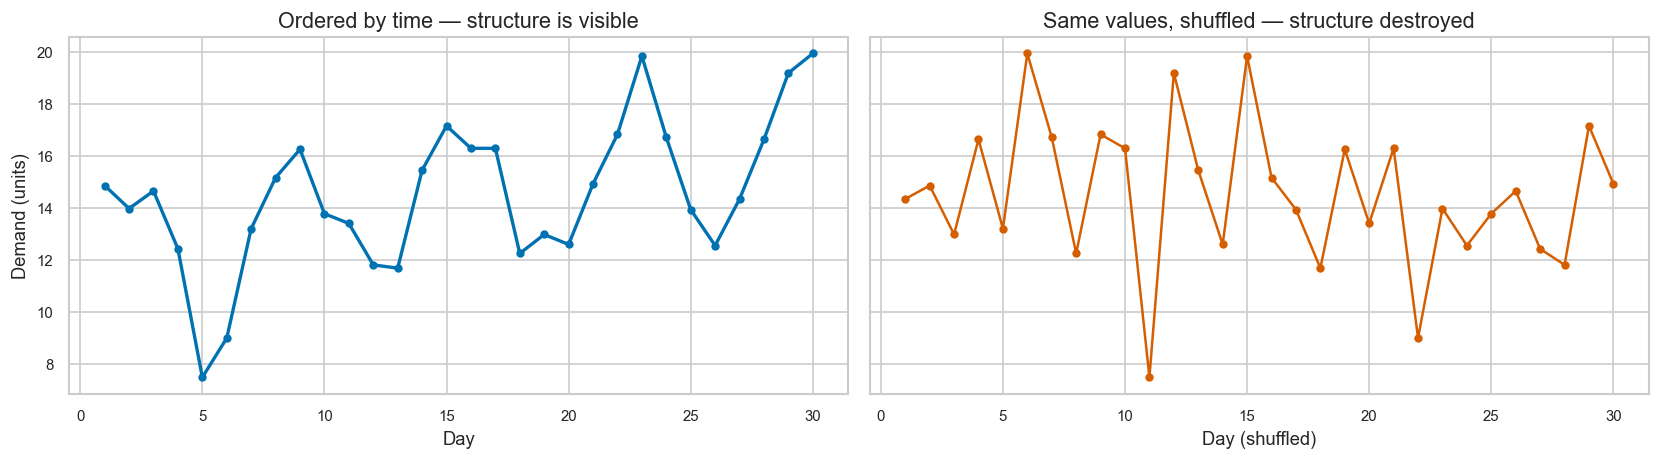

Saved: 01_time_series_basics.png


In [2]:
# Synthetic daily demand (30 days) - visible ordering
days = np.arange(1, 31)
level = 12
trend = 0.15 * days
seasonal = 3 * np.sin(2 * np.pi * days / 7)
noise = rng.normal(0, 1.2, size=30)
y_ordered = level + trend + seasonal + noise
y_shuffled = rng.permutation(y_ordered)

fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)
axes[0].plot(days, y_ordered, marker="o", color="#0072B2", lw=2, ms=4)
axes[0].set_title("Ordered by time — structure is visible")
axes[0].set_xlabel("Day"); axes[0].set_ylabel("Demand (units)")

axes[1].plot(days, y_shuffled, marker="o", color="#D55E00", lw=1.5, ms=4)
axes[1].set_title("Same values, shuffled — structure destroyed")
axes[1].set_xlabel("Day (shuffled)")

plt.tight_layout()
plt.savefig(FIG_DIR / "01_time_series_basics.png", bbox_inches="tight", dpi=150)
plt.show()
print("Saved: 01_time_series_basics.png")

> **Reading the chart:** Left — a clear upward drift with a weekly wiggle. Right — the same 30 numbers shuffled: the drift and seasonality vanish. This is why time-series models must respect order. Shuffling is a valid test for image data; it is invalid for demand forecasting.

**Mathematics (light):** We denote the series as $y_1, y_2, \dots, y_T$ where $t$ is time. A forecast $\hat{y}_{t+h \mid t}$ is made at time $t$ for $h$ steps ahead. $h=1$ is tomorrow, $h=28$ is four weeks ahead in our experiment.

---

# 2. Level

## 2.1 Definition

**Level** is the underlying typical magnitude around which demand fluctuates — the centre of gravity of the series if you removed short-term wiggles.

> **Layman:** If a shop sells ~100 units/day on average, 100 is the level — even though any single day might be 85 or 115.

Observed demand $\approx$ underlying level $+$ temporary variation. Level is **not** the latest observation; it is a smoothed concept.

## 2.2 Why level matters for inventory

If the system believes the level is 100 units/day, it plans replenishment around 100. If the level has actually shifted to 130 but the forecast still assumes 100, every future order will be too small — chronic under-stocking.

## 2.3 Visual — low / medium / high level

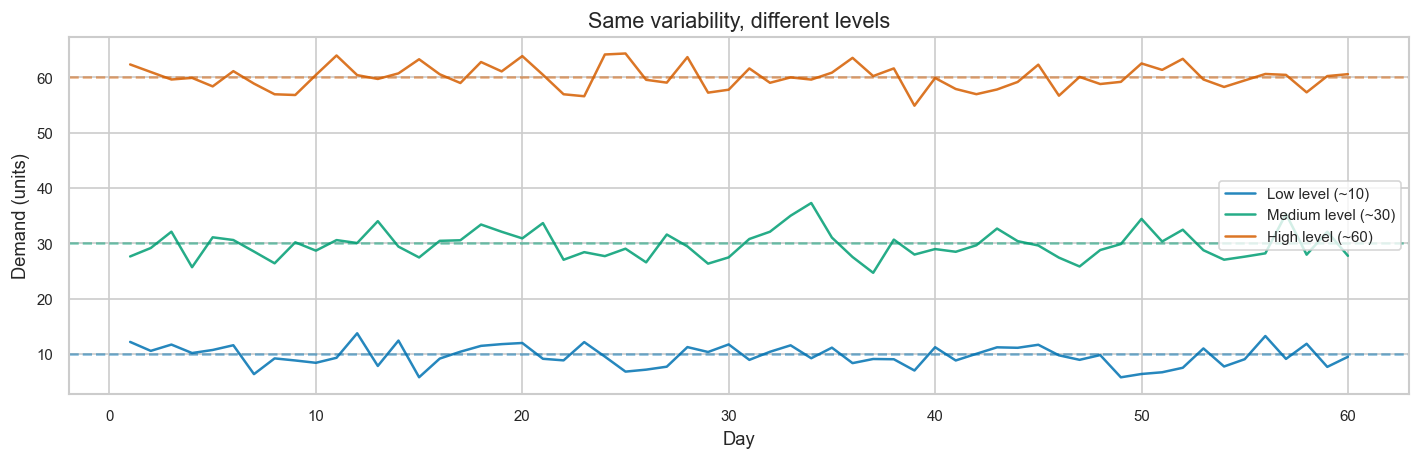

Saved: 02_level.png


In [3]:
fig, ax = plt.subplots(figsize=(12, 4))
x = np.arange(1, 61)
for lvl, color, label in [(10, "#0072B2", "Low level (~10)"), (30, "#009E73", "Medium level (~30)"), (60, "#D55E00", "High level (~60)")]:
    y = lvl + rng.normal(0, 2.5, size=len(x))
    ax.plot(x, y, color=color, lw=1.5, alpha=0.85, label=label)
    ax.axhline(lvl, color=color, ls="--", alpha=0.5)
ax.set_title("Same variability, different levels")
ax.set_xlabel("Day"); ax.set_ylabel("Demand (units)")
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "02_level.png", bbox_inches="tight", dpi=150)
plt.show()
print("Saved: 02_level.png")

> **Reading the chart:** Three series with identical noise but different centres (dashed lines). The *level* is the dashed line; the wiggly line is what we actually observe.

**Takeaway:** A model that confuses a noisy day for a new level will over-react. A good model estimates level *through* the noise, not *from* one noisy point.

---

# 3. Trend

## 3.1 Definition

**Trend** is a persistent upward or downward movement in the underlying series — not a one-day blip.

> Short-term movement vs trend: 100 → 115 → 98 is noise; 100 → 102 → 105 → 108 → 112 is a trend.

## 3.2 Why trend fools simple models

A model that only copies the last observation (Naive) will **underestimate** every future day when trend is positive, and **overestimate** when trend is negative — the error compounds over the 28-day horizon.

## 3.3 Visual — positive / negative / no trend

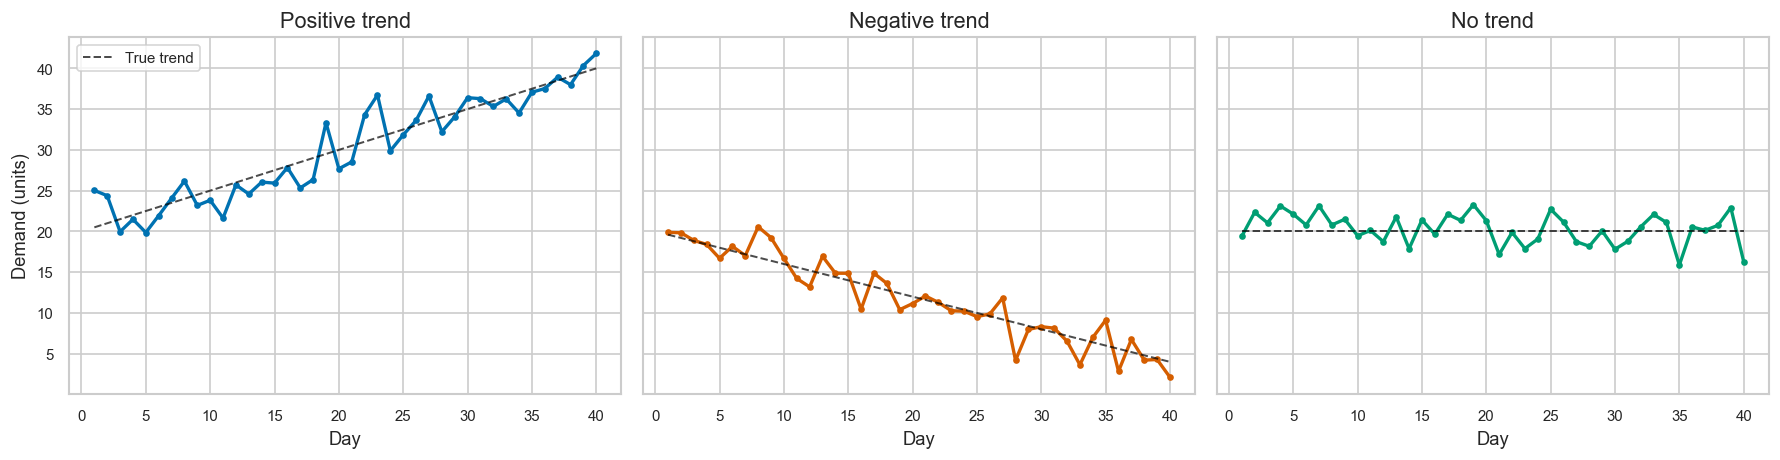

Saved: 03_trend.png


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
x = np.arange(1, 41)
for ax, slope, title, color in zip(axes, [0.5, -0.4, 0.0], ["Positive trend", "Negative trend", "No trend"], ["#0072B2", "#D55E00", "#009E73"]):
    y = 20 + slope * x + rng.normal(0, 1.8, size=len(x))
    ax.plot(x, y, color=color, lw=2, marker="o", ms=3)
    # true trend line
    ax.plot(x, 20 + slope * x, color="black", ls="--", lw=1.2, alpha=0.7, label="True trend")
    ax.set_title(title)
    ax.set_xlabel("Day")
axes[0].set_ylabel("Demand (units)")
axes[0].legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "03_trend.png", bbox_inches="tight", dpi=150)
plt.show()
print("Saved: 03_trend.png")

> **Reading the chart:** Dashed black = true trend; coloured = observed demand. Positive trend rises despite noise; negative trend falls; flat trend wiggles around a constant.

**Numerical example:**

```
Day 1: 100
Day 2: 102  (+2)
Day 3: 105  (+3)
Day 4: 108  (+3)
Day 5: 112  (+4)  →  clear upward trend, not just noise
```

A Naive forecast from Day 5 (=112) for Day 6 would be 112 — but if the trend continues, the true demand may be ~115, so Naive already lags.

**Misleading apparent trend:** A short run 100 → 105 → 103 → 108 can look like a trend but may be random. Real trend requires persistence — that's why longer windows help distinguish signal from noise.

---

# 4. Seasonality

## 4.1 Definition

**Seasonality** is a pattern that repeats at a known, consistent period $m$.

For daily retail demand, the dominant period is **weekly**: $m = 7$ days. Monday behaves like Monday, Saturday like Saturday.

> Seasonality is predictable repetition — not one-off spikes.

| Period $m$ | Retail example |
|---|---|
| 7 (weekly) | Weekday vs weekend |
| 30 (monthly) | Payday effects |
| 365 (yearly) | Holiday seasons |
| 7 × 52 (yearly weekly) | Same week last year |

## 4.2 Why $m=7$ in our project?

Not arbitrary. Our EDA (Notebook 03 for M5, and Notebook 02b for Store Item Demand) found:

- **M5:** detectable weekly structure in aggregate demand.
- **Store Item Demand:** strong weekly seasonality — Seasonal Naive was the strongest baseline, confirming the pattern is strong enough to forecast better than Naive.

## 4.3 Visual — weekly seasonality repeating

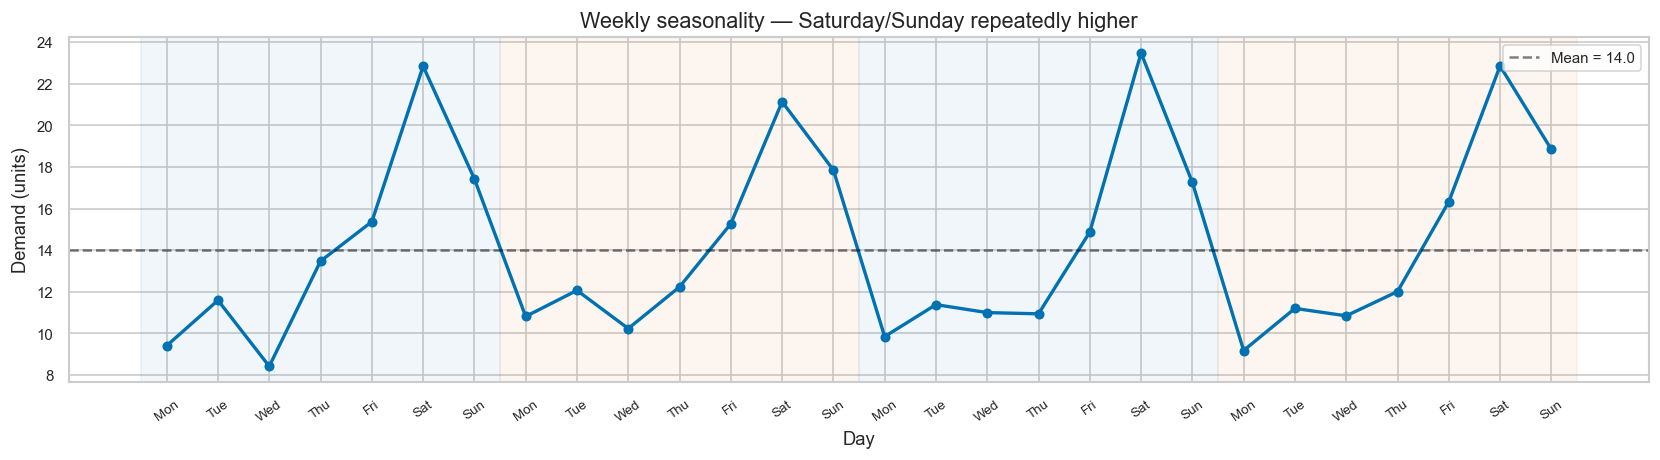

Saved: 04_seasonality.png


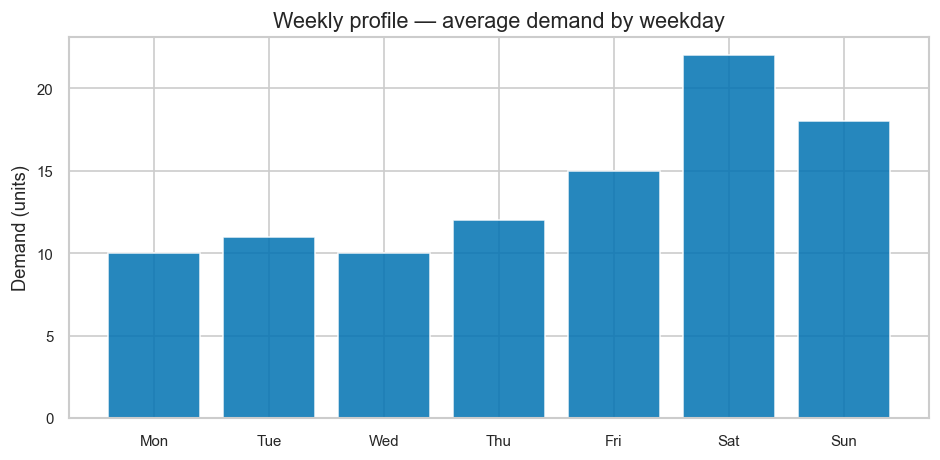

Saved: 04b_weekly_profile.png


In [5]:
# Synthetic weekly pattern: Sat/Sun higher
weekly = np.array([10, 11, 10, 12, 15, 22, 18], dtype=float)  # Mon..Sun
days = np.arange(1, 29)
y_weekly = np.tile(weekly, 4) + rng.normal(0, 1.0, size=28)

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(days, y_weekly, marker="o", color="#0072B2", lw=2, ms=5)
for wk in range(4):
    ax.axvspan(wk*7+0.5, wk*7+7.5, alpha=0.06, color="#0072B2" if wk%2==0 else "#D55E00")
ax.set_xticks(days)
ax.set_xticklabels(["Mon","Tue","Wed","Thu","Fri","Sat","Sun"]*4, rotation=35, fontsize=8)
ax.set_title("Weekly seasonality — Saturday/Sunday repeatedly higher")
ax.set_xlabel("Day"); ax.set_ylabel("Demand (units)")
ax.axhline(weekly.mean(), color="black", ls="--", alpha=0.5, label=f"Mean = {weekly.mean():.1f}")
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "04_seasonality.png", bbox_inches="tight", dpi=150)
plt.show()
print("Saved: 04_seasonality.png")

# Also show the weekly profile (average by weekday)
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(range(7), weekly, color="#0072B2", edgecolor="white", alpha=0.85)
ax.set_xticks(range(7)); ax.set_xticklabels(["Mon","Tue","Wed","Thu","Fri","Sat","Sun"])
ax.set_title("Weekly profile — average demand by weekday")
ax.set_ylabel("Demand (units)")
plt.tight_layout()
plt.savefig(FIG_DIR / "04b_weekly_profile.png", bbox_inches="tight", dpi=150)
plt.show()
print("Saved: 04b_weekly_profile.png")

> **Reading the charts:** Top — 4 weeks of daily demand; shading marks weeks. The Sat/Sun peaks repeat. Bottom — the *profile* (average by weekday) makes the pattern explicit: Sat = 22, Sun = 18, Mon–Thu ≈ 10–12.

**Takeaway:** If a model ignores this structure (e.g., Naive), every Saturday forecast will be systematically low. Seasonal Naive directly copies the corresponding weekday and avoids that bias.

---

# 5. Noise / Irregular Component

## 5.1 Definition

**Noise** is variation that cannot be explained by the systematic components we choose to model. It is the residual after removing level, trend, and seasonality.

```
Observed  =  Signal (level + trend + seasonality)  +  Noise
```

Noise is **not** bad data. It represents customer randomness, small operational effects, or unobserved variables — inherent uncertainty.

## 5.2 Why it matters

| Noise level | Forecasting difficulty | Inventory implication |
|---|---|---|
| Low | Signal dominates — easier to forecast | Less safety stock needed |
| High | Noise dominates — harder to forecast | More safety stock to cover uncertainty |

> A perfect forecast cannot eliminate noise — only a probabilistic view (uncertainty, safety stock) can manage it.

## 5.3 Visual — low / medium / high noise

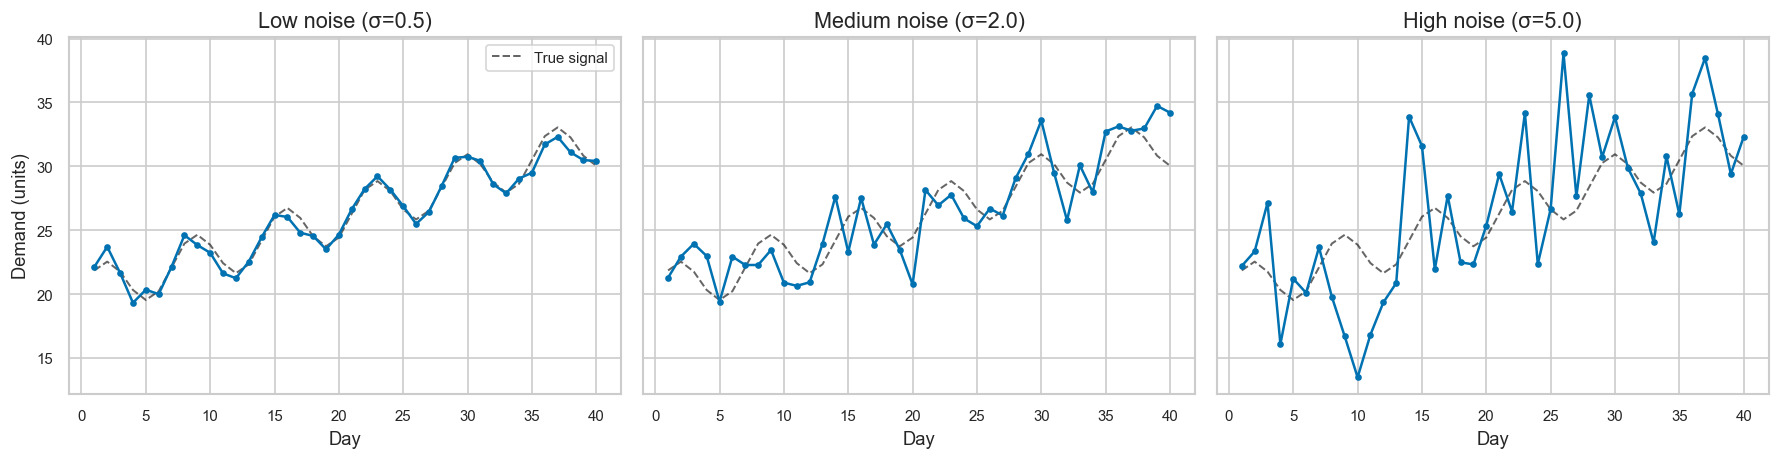

Saved: 05_noise.png


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
x = np.arange(1, 41)
base = 20 + 0.3 * x + 2 * np.sin(2*np.pi*x/7)
for ax, sigma, title in zip(axes, [0.5, 2.0, 5.0], ["Low noise (σ=0.5)", "Medium noise (σ=2.0)", "High noise (σ=5.0)"]):
    y = base + rng.normal(0, sigma, size=len(x))
    ax.plot(x, base, color="black", ls="--", lw=1.2, alpha=0.6, label="True signal")
    ax.plot(x, y, color="#0072B2", lw=1.5, marker="o", ms=3)
    ax.set_title(title)
    ax.set_xlabel("Day")
axes[0].set_ylabel("Demand (units)")
axes[0].legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "05_noise.png", bbox_inches="tight", dpi=150)
plt.show()
print("Saved: 05_noise.png")

> **Reading the chart:** Dashed black = true signal (level + trend + seasonality); blue = observed. As σ grows, the signal is increasingly hidden — any point forecast will be less precise, and inventory must carry more buffer.

**Key distinctions:**
- **Noise ≠ error:** Noise is in the data-generating process; forecast error is the gap between our prediction and the (noisy) reality.
- **Intermittency is not just noise:** Frequent zeros in M5 are a structural feature, not just high variance — they need different handling than dense noise.

---

# 6. Putting the Components Together

## 6.1 Intuition first

```
Observed Demand  ≈  Level  +  Trend  +  Seasonality  +  Noise
```

Each term has a job: level = where we are, trend = where we are heading, seasonality = repeating calendar effect, noise = what we cannot explain.

## 6.2 Additive form (mathematics)

$$y_t = \ell_t + b_t + s_t + \varepsilon_t$$

- $y_t$ — observed demand at time $t$
- $\ell_t$ — level (smoothed local mean)
- $b_t$ — trend (local slope)
- $s_t$ — seasonal component (e.g., weekday effect, period $m=7$)
- $\varepsilon_t$ — irregular / noise, $E[\varepsilon_t]=0$

This is the **additive** decomposition — components add. (Multiplicative, where they multiply, is discussed next.)

## 6.3 Visual — synthetic series with known components

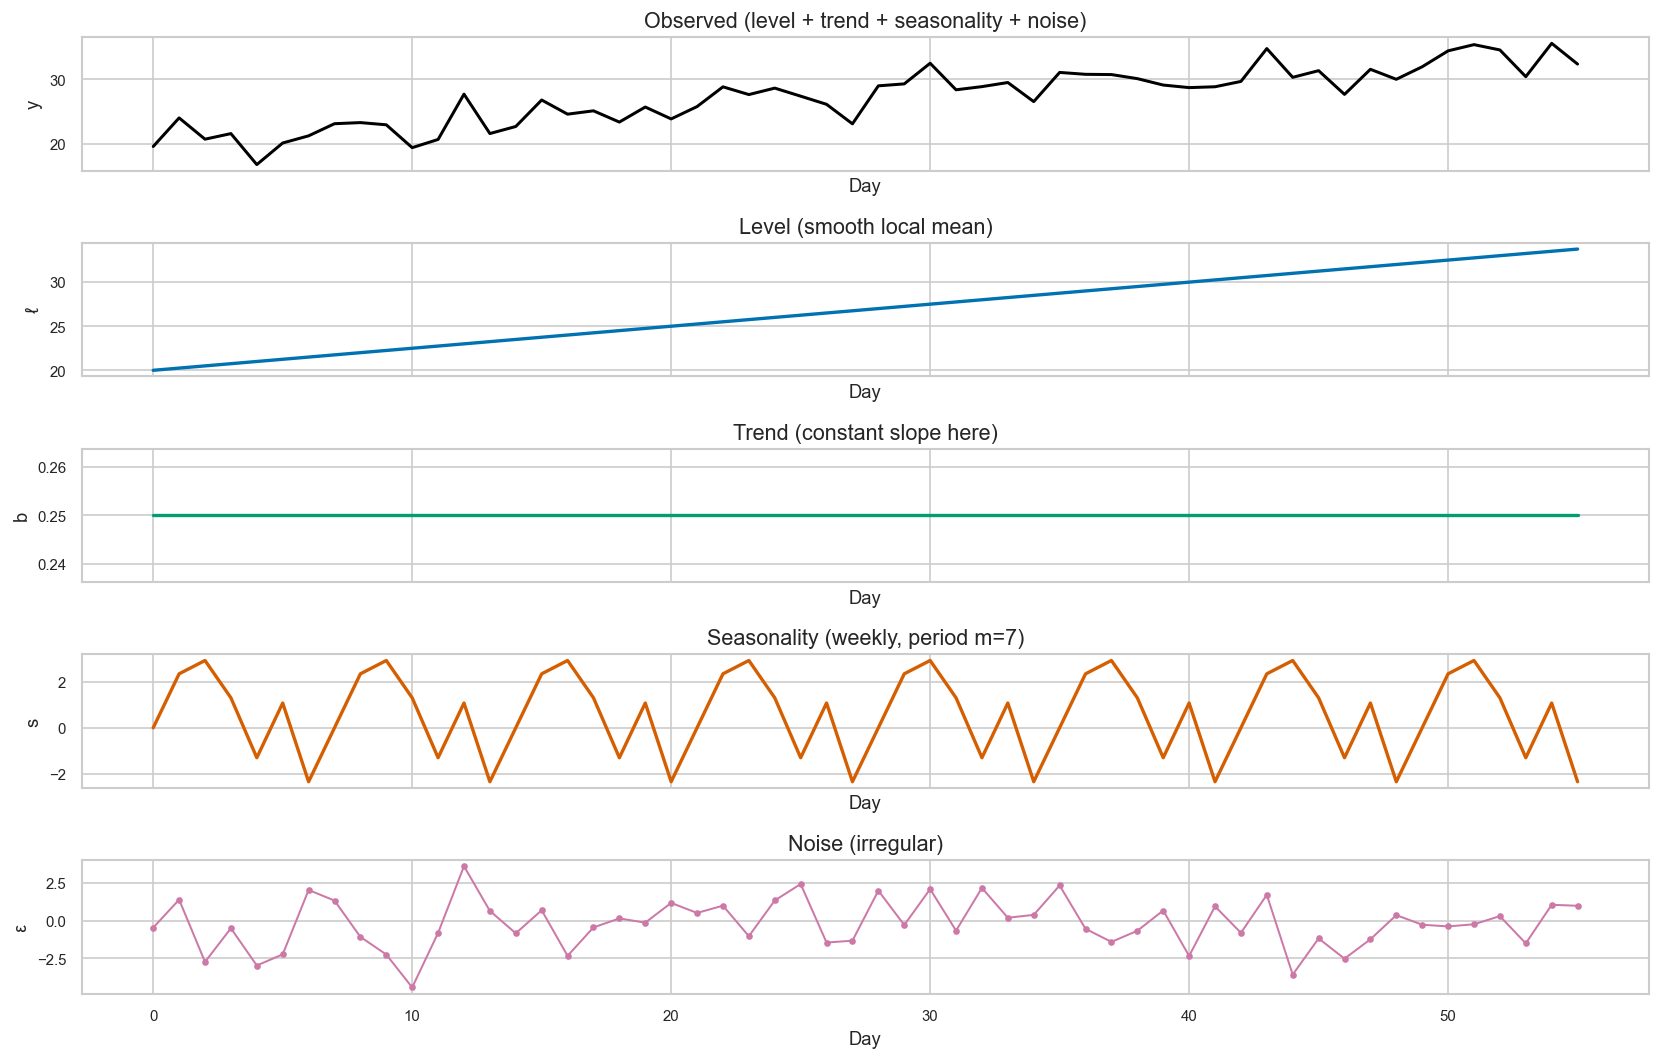

Saved: 06_components_combined.png


In [7]:
# Known synthetic components
n = 56  # 8 weeks
t = np.arange(n)
level_true = 20 + 0.25 * t
trend_true = 0.25 * np.ones(n)  # constant slope for illustration
seasonal_true = 3 * np.sin(2*np.pi*t/7) + np.where(t % 7 == 5, 4, 0)  # Sat boost
noise_true = rng.normal(0, 1.5, size=n)
y_true = level_true + seasonal_true + noise_true

fig, axes = plt.subplots(5, 1, figsize=(14, 9), sharex=True)
axes[0].plot(t, y_true, color="black", lw=1.8)
axes[0].set_title("Observed (level + trend + seasonality + noise)"); axes[0].set_ylabel("y")
axes[1].plot(t, level_true, color="#0072B2", lw=2)
axes[1].set_title("Level (smooth local mean)"); axes[1].set_ylabel("ℓ")
axes[2].plot(t, trend_true, color="#009E73", lw=2)
axes[2].set_title("Trend (constant slope here)"); axes[2].set_ylabel("b")
axes[3].plot(t, seasonal_true, color="#D55E00", lw=2)
axes[3].set_title("Seasonality (weekly, period m=7)"); axes[3].set_ylabel("s")
axes[4].plot(t, noise_true, color="#CC79A7", lw=1.2, marker="o", ms=3)
axes[4].set_title("Noise (irregular)"); axes[4].set_ylabel("ε")
for ax in axes: ax.set_xlabel("Day")
plt.tight_layout()
plt.savefig(FIG_DIR / "06_components_combined.png", bbox_inches="tight", dpi=150)
plt.show()
print("Saved: 06_components_combined.png")

> **Reading the chart:** Five panels share the same time axis. Top = what we observe; below = the hidden structure that generated it. A good decomposition recovers the bottom four from the top one. In real data the components are *inferred*, not known — the quality of that inference determines forecast quality.

---

# 7. Additive vs Multiplicative Structure

## 7.1 When does each apply?

| Structure | Equation | Meaning | When to use |
|---|---|---|---|
| **Additive** | $y = \ell + b + s + \varepsilon$ | Seasonal effect is **constant** in units | Stable retail, low growth |
| **Multiplicative** | $y = \ell \times b \times s \times \varepsilon$ | Seasonal effect **scales** with level | Growing business, seasonal amplitude grows |

> **Layman:** Additive = "Saturday is +12 units above the level, regardless of level." Multiplicative = "Saturday is ×1.4 the level, so at higher levels the Saturday bump is larger in units."

## 7.2 Visual — both structures on the same growing level

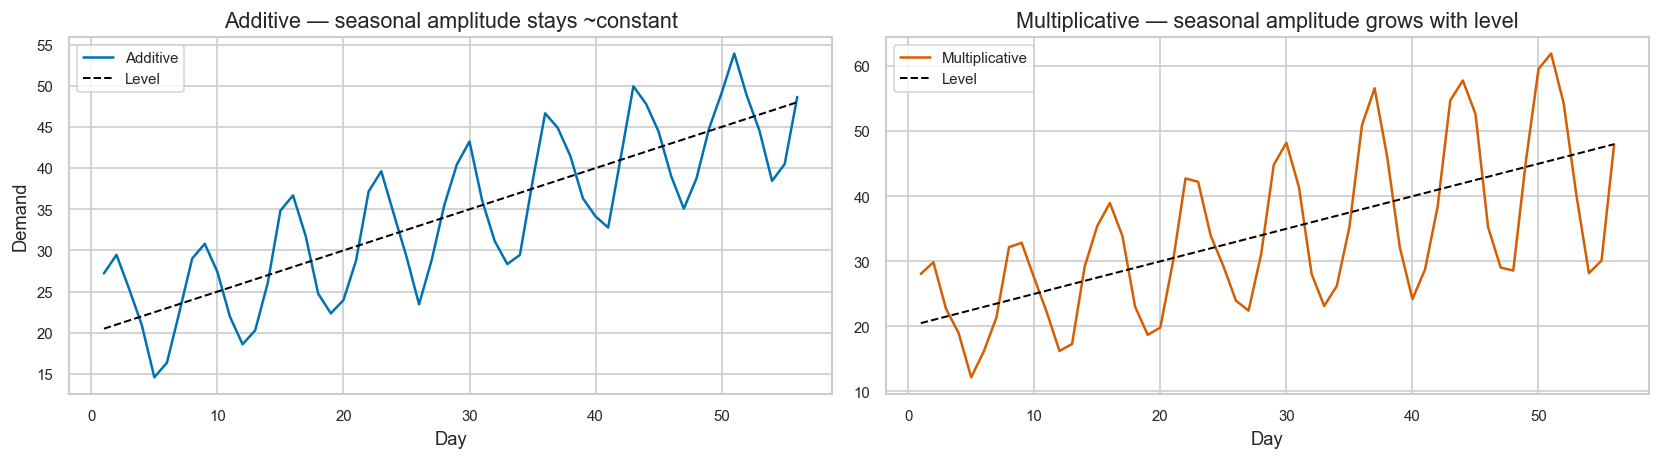

Saved: 07_additive_vs_multiplicative.png


In [8]:
x = np.arange(1, 57)
lvl = 20 + 0.5 * x
add_seasonal = 8 * np.sin(2*np.pi*x/7)
add_y = lvl + add_seasonal + rng.normal(0, 1.2, size=len(x))
mult_seasonal = 0.4 * np.sin(2*np.pi*x/7)  # ±40% swing
mult_y = lvl * (1 + mult_seasonal) + rng.normal(0, 1.5, size=len(x))

fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=False)
axes[0].plot(x, add_y, color="#0072B2", lw=1.5, label="Additive")
axes[0].plot(x, lvl, color="black", ls="--", lw=1.2, label="Level")
axes[0].set_title("Additive — seasonal amplitude stays ~constant")
axes[0].set_xlabel("Day"); axes[0].set_ylabel("Demand"); axes[0].legend()

axes[1].plot(x, mult_y, color="#D55E00", lw=1.5, label="Multiplicative")
axes[1].plot(x, lvl, color="black", ls="--", lw=1.2, label="Level")
axes[1].set_title("Multiplicative — seasonal amplitude grows with level")
axes[1].set_xlabel("Day"); axes[1].legend()

plt.tight_layout()
plt.savefig(FIG_DIR / "07_additive_vs_multiplicative.png", bbox_inches="tight", dpi=150)
plt.show()
print("Saved: 07_additive_vs_multiplicative.png")

> **Reading the chart:** Left — seasonal wiggles stay the same height as the level rises. Right — wiggles stretch as the level rises. Our baselines and exponential smoothing in this project use **additive** seasonality (simpler, matches our weekly retail setting and the 28-day horizon).

**Practical note:** Choosing additive vs multiplicative is a modelling assumption. A wrong choice does not destroy forecasting but can bias seasonal peaks. Yearly seasonality often needs multiplicative handling; weekly retail seasonality is usually well-approximated as additive.

---

# 8. Real Data: M5

We now look at **actual M5 demand** from the frozen experimental sample (500 stratified series, common window 2013-01-01 → 2016-05-22). We select representative series covering each archetype.

> If a component is weak or unclear, we say so — not every series has every pattern.

In [9]:
# --- Load M5 real data (uses frozen selection) ---
from pathlib import Path
M5_RAW = PROJ / "02_data/dataset_01_m5/raw"
M5_PROC = PROJ / "02_data/dataset_01_m5/processed"

cal = pd.read_csv(M5_RAW / "calendar.csv")
# map d_1..d_1941 etc is in calendar.csv; we need dates for common window
# common window defined in 05_experiments/config.json
cfg = json.load(open(PROJ / "05_experiments/config.json"))
common_start = pd.Timestamp(cfg["common_window"]["start"])
common_end = pd.Timestamp(cfg["common_window"]["end"])

# Load sales (evaluation contains full common window)
m5_wide = pd.read_csv(M5_RAW / "sales_train_evaluation.csv")
# d_cols are d_1..d_1941
d_cols = [c for c in m5_wide.columns if c.startswith("d_")]
# Build date mapping from calendar
cal["date"] = pd.to_datetime(cal["date"])
d_to_date = dict(zip(cal["d"], cal["date"]))
# select columns whose date is in common window
common_d_cols = [c for c in d_cols if common_start <= d_to_date[c] <= common_end]
print(f"Common window d-cols: {len(common_d_cols)} (expected 1238)")

# Load series selection
sel = json.load(open(PROJ / "05_experiments/m5_series_selection.json"))
# keys are like FOODS_1_098_CA_3_validation -> map to evaluation id for lookup
sel_ids_val = sel["m5_series"] if "m5_series" in sel else sel.get("selected_ids", [])
# build map validation -> evaluation suffix
id_map = {vid: vid.replace("_validation","_evaluation") for vid in sel_ids_val}
sel_ids_eval = [id_map[vid] for vid in sel_ids_val]

# Load archetype profile for picking representatives
prof = pd.read_csv(M5_PROC / "m5_series_profile.csv")
# prof id column name may vary — normalise
id_col = "id" if "id" in prof.columns else prof.columns[0]
prof["id_eval"] = prof[id_col].astype(str).str.replace("_validation","_evaluation")
# keep only selected
prof_sel = prof[prof["id_eval"].isin(sel_ids_eval)].copy()
print(f"Selected series in profile: {len(prof_sel)} / {len(sel_ids_eval)}")
print(prof_sel["archetype"].value_counts().head(10) if "archetype" in prof_sel.columns else "No archetype column")

# Build long-format for quick plotting: wide -> indexed
m5_common = m5_wide.set_index("id")[common_d_cols]
# dates for x-axis
dates_common = pd.to_datetime([d_to_date[c] for c in common_d_cols])

Common window d-cols: 1238 (expected 1238)


Selected series in profile: 0 / 500
Series([], Name: count, dtype: int64)


Representative M5 series: {'Series 1': 'FOODS_1_098_CA_3_evaluation', 'Series 2': 'FOODS_1_133_TX_3_evaluation', 'Series 3': 'FOODS_1_148_WI_3_evaluation', 'Series 4': 'FOODS_1_072_WI_2_evaluation'}


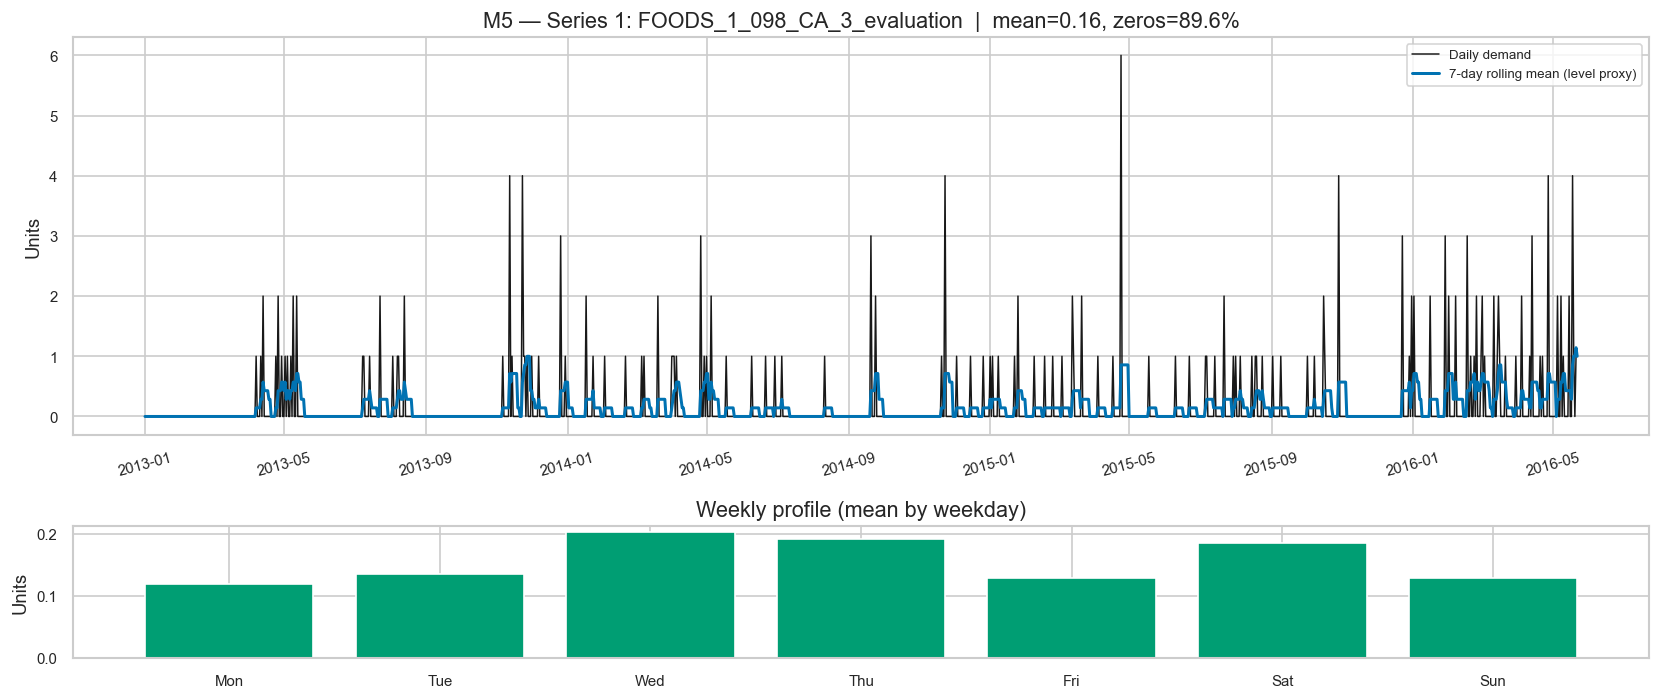

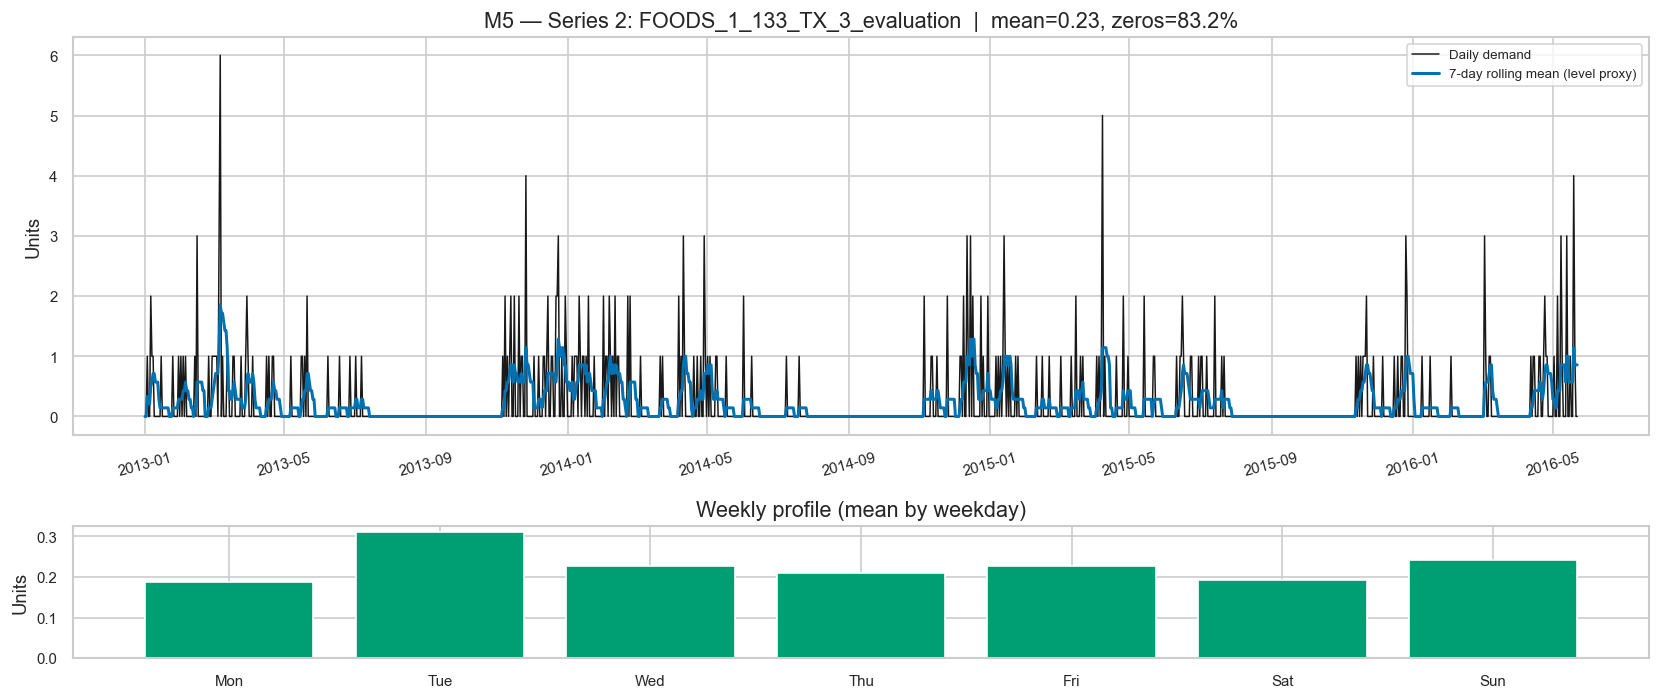

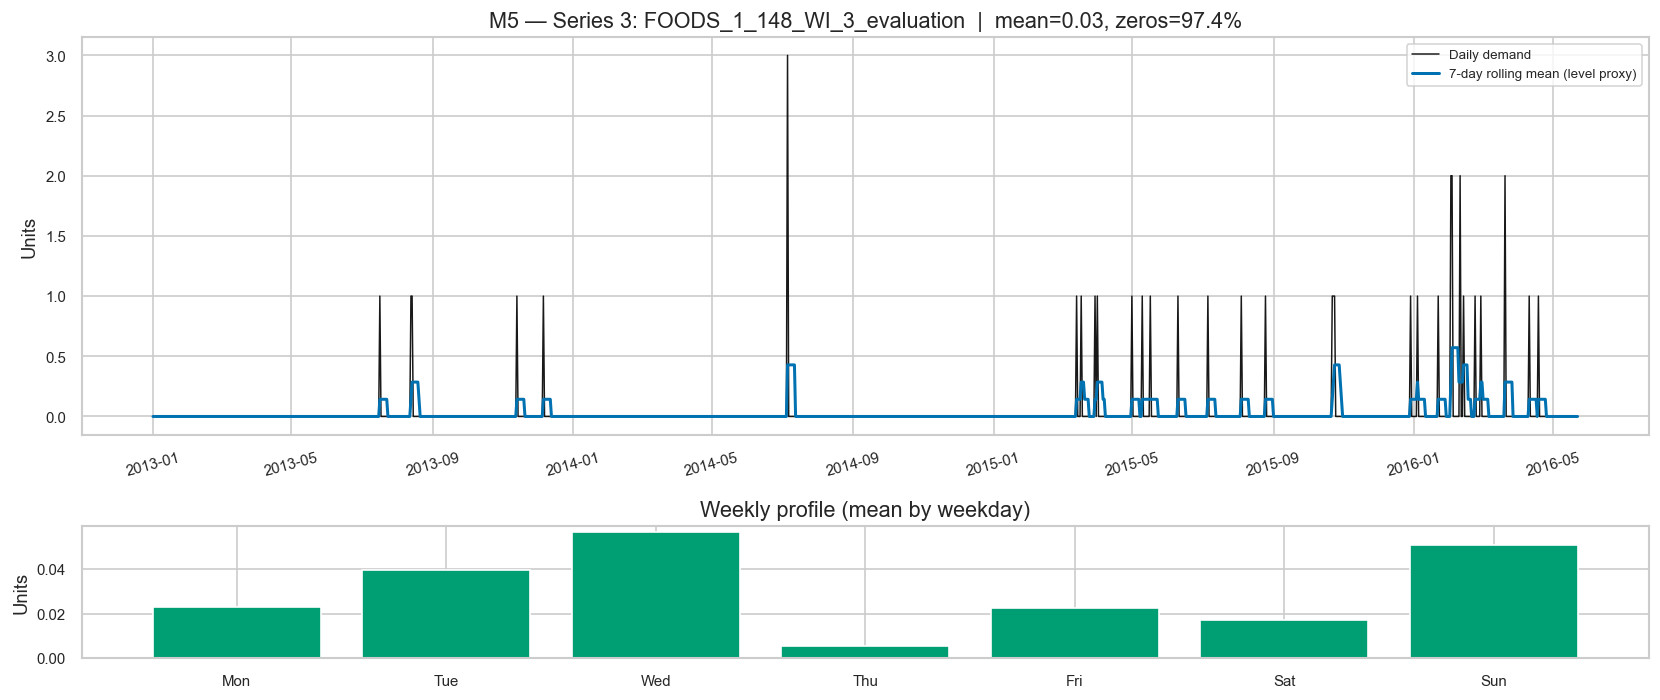

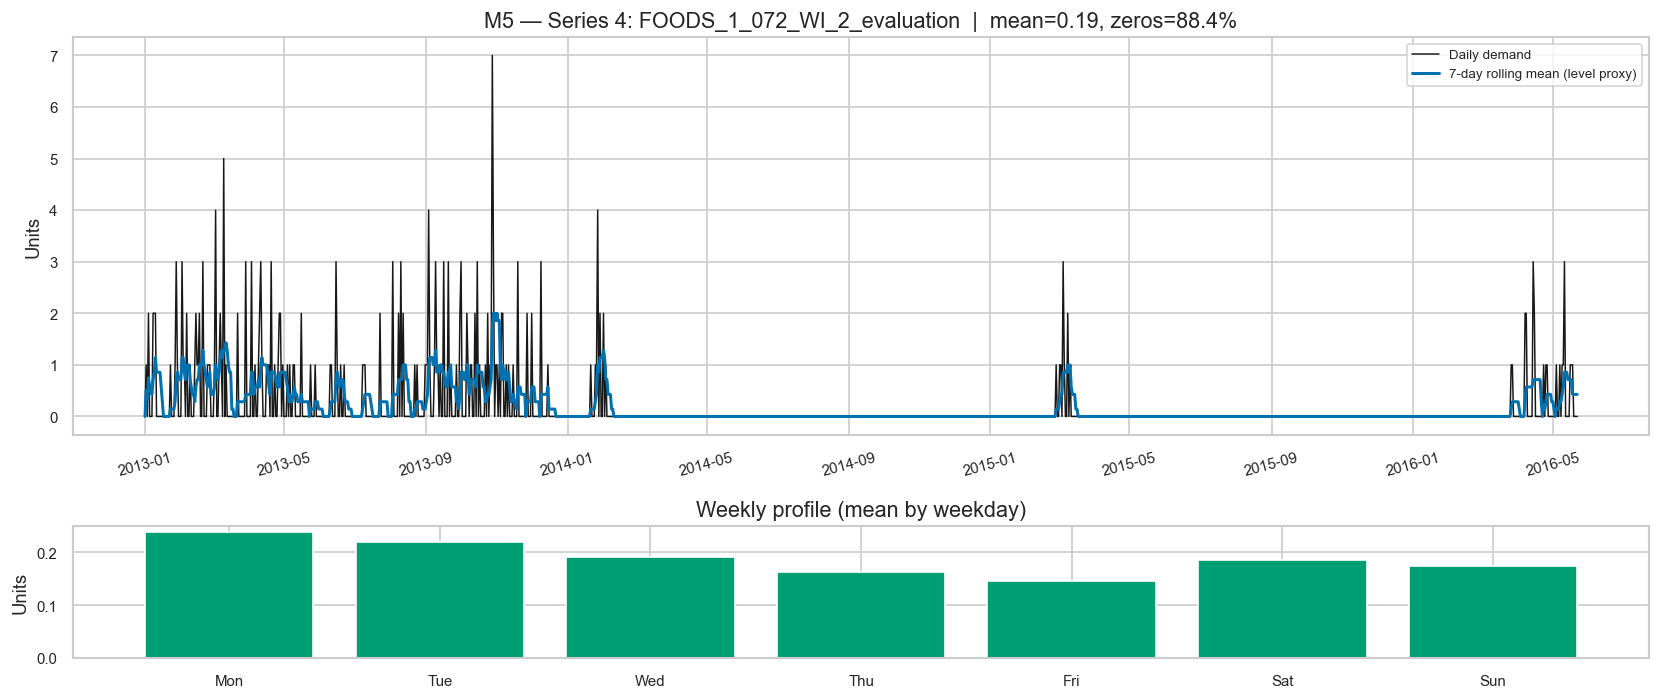

Saved M5 component figures to D:\Brain\07_Research\AI-INVENTORY-OPTIMIZATION\07_figures\model_explanations\time_series_components


In [10]:
# Pick one representative per archetype where available
archetypes = ["Smooth", "Variable", "Intermittent", "Highly Intermittent", "Lumpy"] if "archetype" in prof_sel.columns else []
examples = {}
for arch in archetypes:
    sub = prof_sel[prof_sel["archetype"] == arch]
    if len(sub) > 0:
        # pick median by mean demand
        pick = sub.sort_values("mean" if "mean" in sub.columns else id_col).iloc[len(sub)//2]
        examples[arch] = pick["id_eval"]
# fallback: just pick first few if archetype missing
if not examples:
    for i, sid in enumerate(sel_ids_eval[:4]):
        examples[f"Series {i+1}"] = sid
print("Representative M5 series:", examples)

# Plot each example: raw + 7-day rolling + weekly profile
for arch, sid in examples.items():
    if sid not in m5_common.index:
        print(f"Skip {sid} not in wide table")
        continue
    y = m5_common.loc[sid].values.astype(float)
    s = pd.Series(y, index=dates_common)
    roll7 = s.rolling(7, min_periods=1).mean()
    # weekly profile over the whole common window
    dow = s.index.dayofweek  # 0=Mon
    weekly_mean = s.groupby(dow).mean()

    fig, axes = plt.subplots(2, 1, figsize=(14, 6), gridspec_kw={"height_ratios":[3,1]})
    axes[0].plot(s.index, y, color="black", lw=0.9, alpha=0.9, label="Daily demand")
    axes[0].plot(s.index, roll7, color="#0072B2", lw=1.8, label="7-day rolling mean (level proxy)")
    axes[0].set_title(f"M5 — {arch}: {sid}  |  mean={y.mean():.2f}, zeros={(y==0).mean()*100:.1f}%")
    axes[0].set_ylabel("Units"); axes[0].legend(fontsize=8); axes[0].tick_params(axis="x", rotation=15)

    axes[1].bar(range(7), weekly_mean.values, color="#009E73", edgecolor="white")
    axes[1].set_xticks(range(7)); axes[1].set_xticklabels(["Mon","Tue","Wed","Thu","Fri","Sat","Sun"])
    axes[1].set_title("Weekly profile (mean by weekday)")
    axes[1].set_ylabel("Units")
    plt.tight_layout()
    plt.savefig(FIG_DIR / f"08_m5_{arch.replace(' ','_').lower()}.png", bbox_inches="tight", dpi=150)
    plt.show()

print("Saved M5 component figures to", FIG_DIR)

> **Reading the M5 charts (per archetype):**
> - Top panel: black = daily demand (note frequent zeros in intermittent series), blue = 7-day rolling mean — a simple **level** proxy.
> - Bottom panel: average by weekday — the **weekly seasonality** signal, if any.
> - We report mean and zero-share in the title — the two numbers that most distinguish M5 series.
> - **Interpretation rule:** If the rolling mean is flat, level is stable. If the weekly bars are similar heights, weekly seasonality is weak. If zeros dominate, the series is intermittent and point forecasts will struggle.

**M5 reality:** Most series are intermittent/highly intermittent — level estimation is noisy, weekly seasonality is often weak or masked by zeros, and noise/intermittency dominates. This is why baselines like Moving Average help (they smooth) but cannot solve intermittency itself.

---

# 9. Real Data: Store Item Demand

Dense daily demand (500 series, 1826 days total, 1238 in common window, ~0% zeros, all Smooth in 02b's archetype audit). No sampling ambiguity — we use all 500. The same 7-day rolling and weekly profile views now reveal a very different structure.

Store Item rows in common window: 619,000
Unique series: 500 (expected 500)


Pivot shape: (1238, 500) (dates × series)
Representative Store Item series: {'Low demand': 'store_7_item_5', 'Median demand': 'store_4_item_20', 'High demand': 'store_2_item_28'}


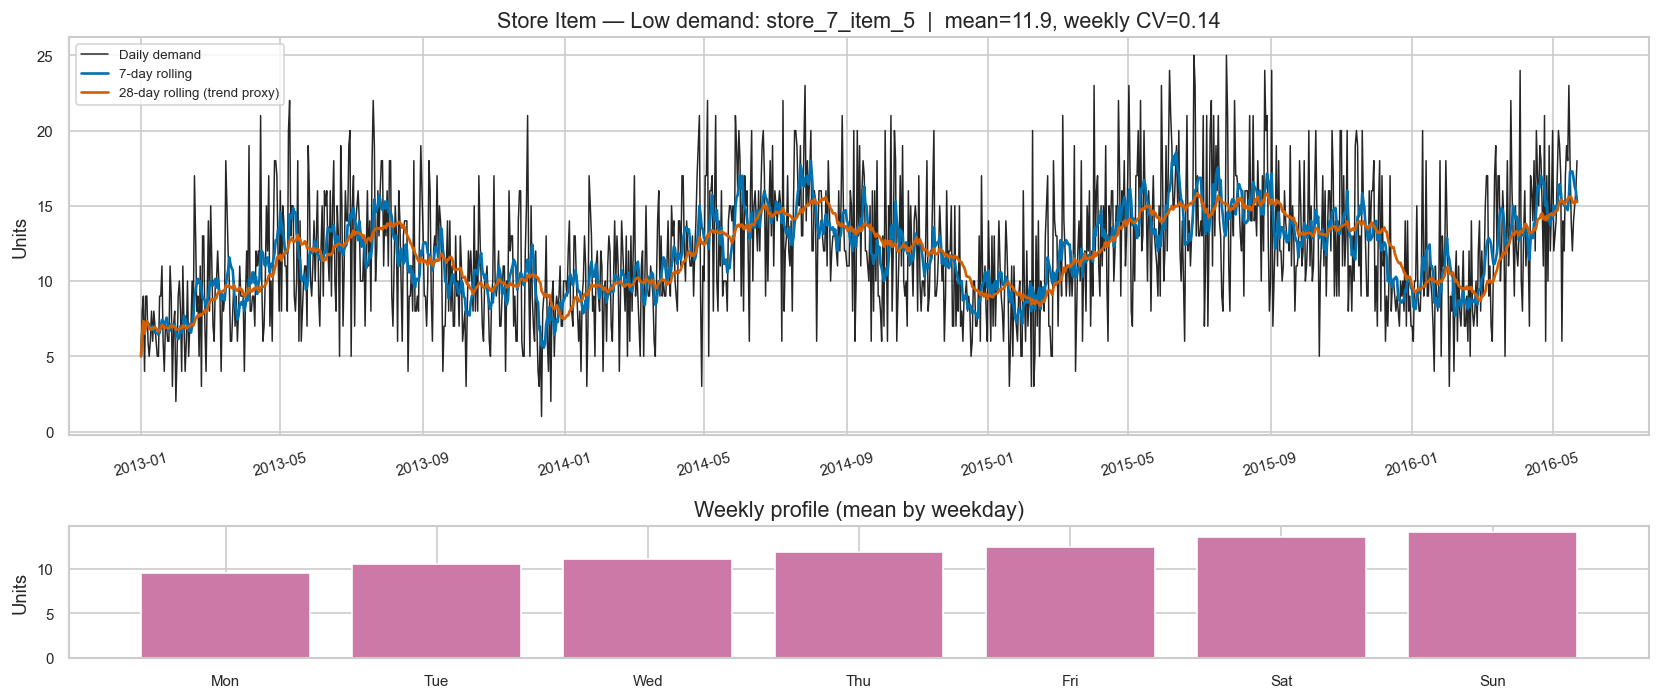

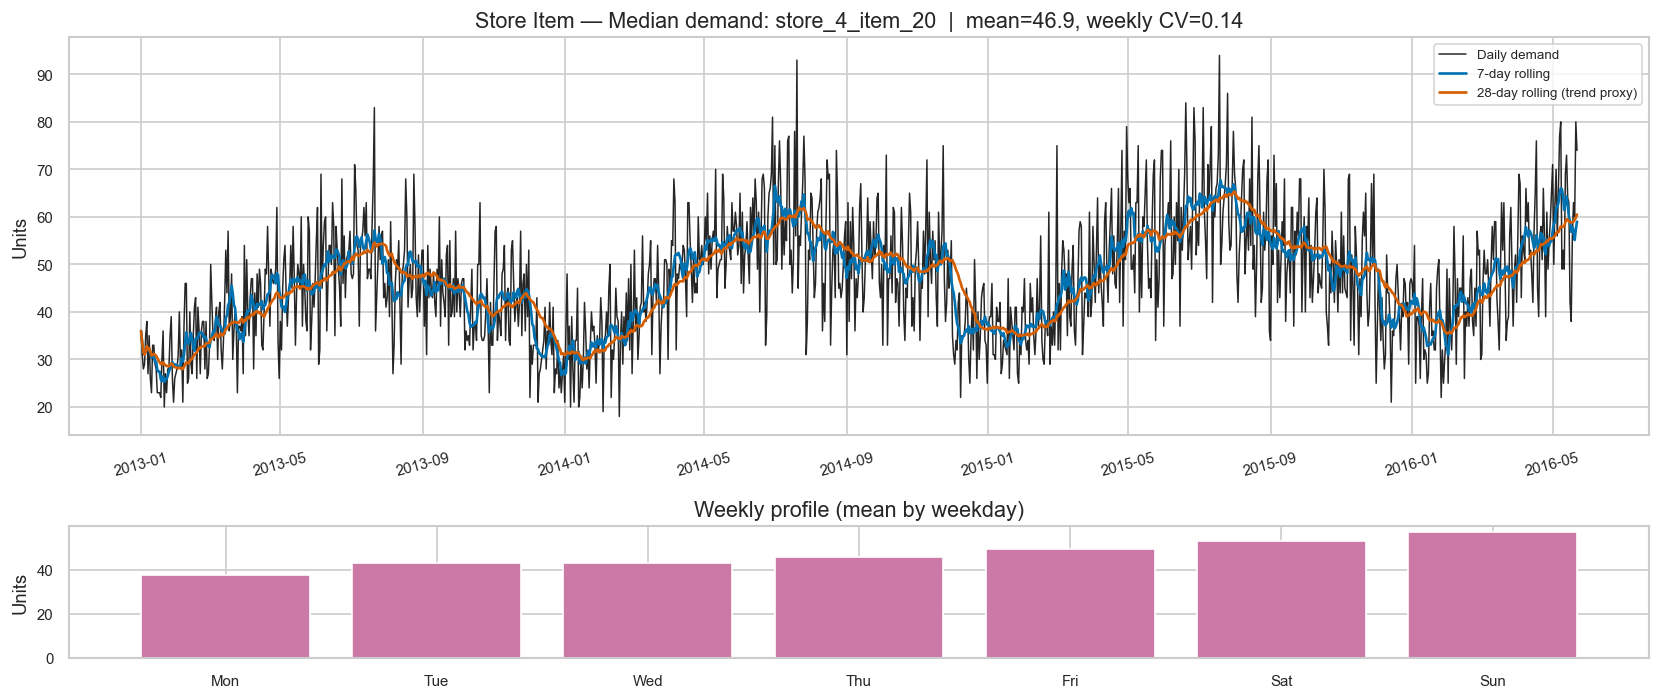

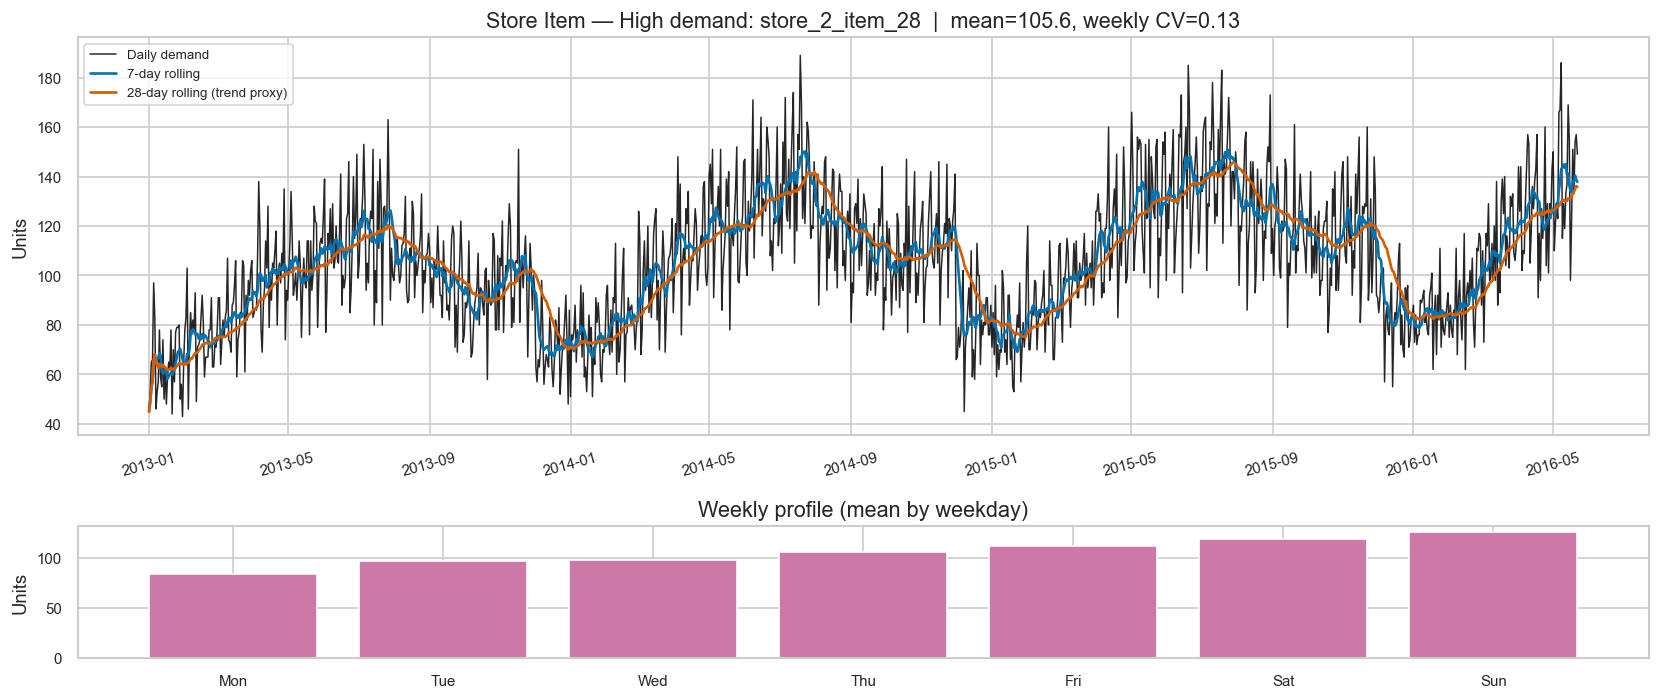

Saved Store Item component figures to D:\Brain\07_Research\AI-INVENTORY-OPTIMIZATION\07_figures\model_explanations\time_series_components


In [11]:
# --- Load Store Item Demand real data ---
SIT_RAW = PROJ / "02_data/dataset_02_store_item_demand/raw"
SIT_PROC = PROJ / "02_data/dataset_02_store_item_demand/processed"

sit = pd.read_csv(SIT_RAW / "train.csv", parse_dates=["date"])
sit = sit[(sit["date"] >= common_start) & (sit["date"] <= common_end)].copy()
sit["series_id"] = "store_" + sit["store"].astype(str) + "_item_" + sit["item"].astype(str)
print(f"Store Item rows in common window: {len(sit):,}")
print(f"Unique series: {sit['series_id'].nunique()} (expected 500)")

# Pivot to wide for plotting convenience (dates x series)
pivot = sit.pivot_table(index="date", columns="series_id", values="sales", aggfunc="sum").sort_index()
pivot = pivot.reindex(dates_common)  # align to same calendar as M5
print(f"Pivot shape: {pivot.shape} (dates × series)")

# Pick representatives: low / median / high mean demand
means = pivot.mean()
# choose 3: low, median, high
low_id = means.nsmallest(1).index[0]
med_id = means.sort_values().iloc[len(means)//2:len(means)//2+1].index[0]
high_id = means.nlargest(1).index[0]
sit_examples = {"Low demand": low_id, "Median demand": med_id, "High demand": high_id}
print("Representative Store Item series:", sit_examples)

for label, sid in sit_examples.items():
    y = pivot[sid].values.astype(float)
    s = pd.Series(y, index=dates_common)
    roll7 = s.rolling(7, min_periods=1).mean()
    roll28 = s.rolling(28, min_periods=1).mean()
    dow = s.index.dayofweek
    weekly_mean = s.groupby(dow).mean()
    weekly_cv = weekly_mean.std() / (weekly_mean.mean() + 1e-9)

    fig, axes = plt.subplots(2, 1, figsize=(14, 6), gridspec_kw={"height_ratios":[3,1]})
    axes[0].plot(s.index, y, color="black", lw=0.9, alpha=0.85, label="Daily demand")
    axes[0].plot(s.index, roll7, color="#0072B2", lw=1.6, label="7-day rolling")
    axes[0].plot(s.index, roll28, color="#D55E00", lw=1.6, label="28-day rolling (trend proxy)")
    axes[0].set_title(f"Store Item — {label}: {sid}  |  mean={y.mean():.1f}, weekly CV={weekly_cv:.2f}")
    axes[0].set_ylabel("Units"); axes[0].legend(fontsize=8); axes[0].tick_params(axis="x", rotation=15)

    axes[1].bar(range(7), weekly_mean.values, color="#CC79A7", edgecolor="white")
    axes[1].set_xticks(range(7)); axes[1].set_xticklabels(["Mon","Tue","Wed","Thu","Fri","Sat","Sun"])
    axes[1].set_title("Weekly profile (mean by weekday)")
    axes[1].set_ylabel("Units")
    plt.tight_layout()
    plt.savefig(FIG_DIR / f"09_store_item_{label.replace(' ','_').lower()}.png", bbox_inches="tight", dpi=150)
    plt.show()

print("Saved Store Item component figures to", FIG_DIR)

> **Reading the Store Item charts:**
> - Top: black = daily demand (dense, rarely zero), blue = 7-day rolling (short-term level), orange = 28-day rolling (slower trend proxy). If orange slopes, there is a trend worth modelling.
> - Bottom: weekly profile — when bars differ clearly, **weekly seasonality is strong** (typical for Store Item).
> - Weekly CV (coefficient of variation across weekdays) quantifies seasonality strength; higher = more to gain from Seasonal Naive / TES.

**Store Item reality:** Level is well-defined, noise is moderate, weekly seasonality is pronounced, zeros are negligible. This is *why* Seasonal Naive already performs well here (02b + 05b) — the weekly repeat is real signal, not noise-chasing.

---

# 10. M5 vs Store Item Demand — Structural Comparison

| Dimension | M5 | Store Item Demand |
|---|---|---|
| Series | 500 stratified from 30,490 | 500 (all) |
| Sparsity | ~68% zeros, many intermittent | ~0% zeros, dense |
| Archetypes (02a/02b) | Smooth / Variable / Intermittent / Highly Intermittent / Lumpy | All Smooth |
| Level clarity | Often obscured by zeros | Clear 7- and 28-day rolling means |
| Weekly seasonality | Detectable in aggregate, weak per intermittent series | Strong per-series weekly profiles |
| Trend | Weak, heterogeneous | Visible gentle drift in many series |
| Baseline winner (05b) | Moving Average (W=14) — smoothing helps | Seasonal Naive — weekly repeat helps |

> Not "good vs bad" — **different forecasting environments.** A model that wins on one may not win on the other, and that is exactly what the ladder tests.

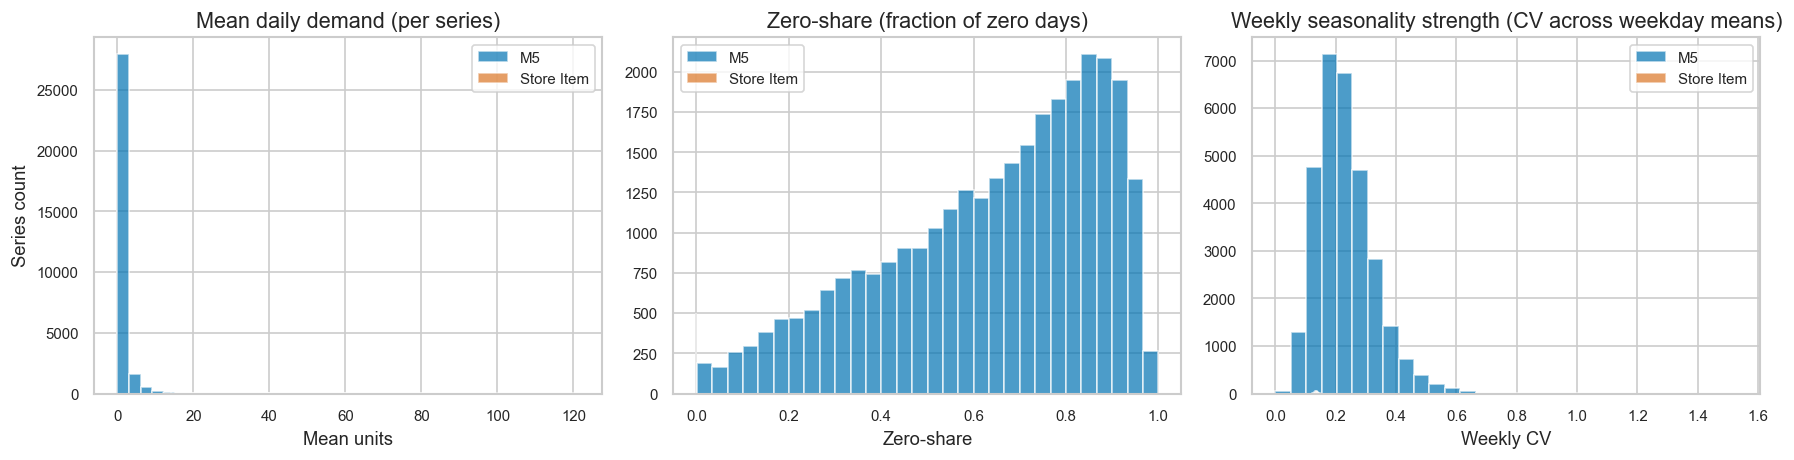

Saved: 10_dataset_structure_comparison.png


In [12]:
# Side-by-side distributions: mean demand, zero-share, weekly CV (Store Item) vs intermittency proxy (M5)
# M5 stats from pivot above + prof
# For fair visual, compare the same 500 vs 500 experimental samples

# M5: mean and zero-share over common window
m5_means = m5_common.mean(axis=1)
m5_zero_share = (m5_common == 0).mean(axis=1)
# Store Item: mean and weekly CV already; zero-share is ~0
sit_means = pivot.mean()
sit_zero_share = (pivot == 0).mean()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].hist(m5_means, bins=40, color="#0072B2", alpha=0.7, edgecolor="white", label="M5")
axes[0].hist(sit_means, bins=40, color="#D55E00", alpha=0.6, edgecolor="white", label="Store Item")
axes[0].set_title("Mean daily demand (per series)")
axes[0].set_xlabel("Mean units"); axes[0].set_ylabel("Series count"); axes[0].legend()

axes[1].hist(m5_zero_share, bins=30, color="#0072B2", alpha=0.7, edgecolor="white", label="M5")
axes[1].hist(sit_zero_share, bins=30, color="#D55E00", alpha=0.6, edgecolor="white", label="Store Item")
axes[1].set_title("Zero-share (fraction of zero days)")
axes[1].set_xlabel("Zero-share"); axes[1].legend()

# Weekly strength: for each series compute CV across weekday means
def weekly_cv_for_frame(frame_long_indexed):
    # frame is dates x series; index is dates
    s_dow = frame_long_indexed.index.dayofweek
    # groupby dow then compute per-series CV; fallback to global if needed
    try:
        grp = frame_long_indexed.groupby(s_dow).mean()
        cv = grp.std() / (grp.mean() + 1e-9)
        return cv
    except Exception:
        return pd.Series(dtype=float)

# For M5, use m5_common transposed to dates x series
m5_dates_x_series = m5_common.T
m5_dates_x_series.index = dates_common
m5_wcv = weekly_cv_for_frame(m5_dates_x_series)
sit_wcv = weekly_cv_for_frame(pivot)
# clip for display
axes[2].hist(m5_wcv.dropna(), bins=30, color="#0072B2", alpha=0.7, edgecolor="white", label="M5")
axes[2].hist(sit_wcv.dropna(), bins=30, color="#D55E00", alpha=0.6, edgecolor="white", label="Store Item")
axes[2].set_title("Weekly seasonality strength (CV across weekday means)")
axes[2].set_xlabel("Weekly CV"); axes[2].legend()

plt.tight_layout()
plt.savefig(FIG_DIR / "10_dataset_structure_comparison.png", bbox_inches="tight", dpi=150)
plt.show()
print("Saved: 10_dataset_structure_comparison.png")

> **Reading the comparison:**
> - Left: M5 means cluster near zero (low-volume, sparse); Store Item means are higher and broader (dense retail).
> - Middle: M5 zero-share spans 0→0.95; Store Item zero-share is near 0.
> - Right: Store Item weekly CV is on average higher — confirming that weekly repetition is a stronger signal there. This explains the baseline results: Seasonal Naive shines where weekly CV is high, Moving Average helps where zero-share is high.

---

# 11. Why Components Matter for Model Selection

Forecasting models are not "better because more complex." The right model is the one whose **assumptions match the structure** we just characterised.

```
No structure understood
        ↓
      Naive  (recent level only)
        ↓  Seasonal structure detected
  Seasonal Naive  (weekly repeat, m=7)
        ↓  Noise reduction useful
  Moving Average  (smoothed level, window W)
        ↓  Level + trend + seasonality need explicit states
  Exponential Smoothing (SES / DES / TES)
        ↓  Autocorrelation structure beyond smoothing
      ARIMA / SARIMA
        ↓  Nonlinear temporal relationships
      LSTM
        ↓  Reasoning over patterns + context
   LLM-based forecasting
```

**Decision rule:** Start simple. Add complexity only when the data shows structure that the simpler model cannot represent, and when the evaluation (same window, same horizon, same metrics) shows the added complexity pays off *out-of-sample*.

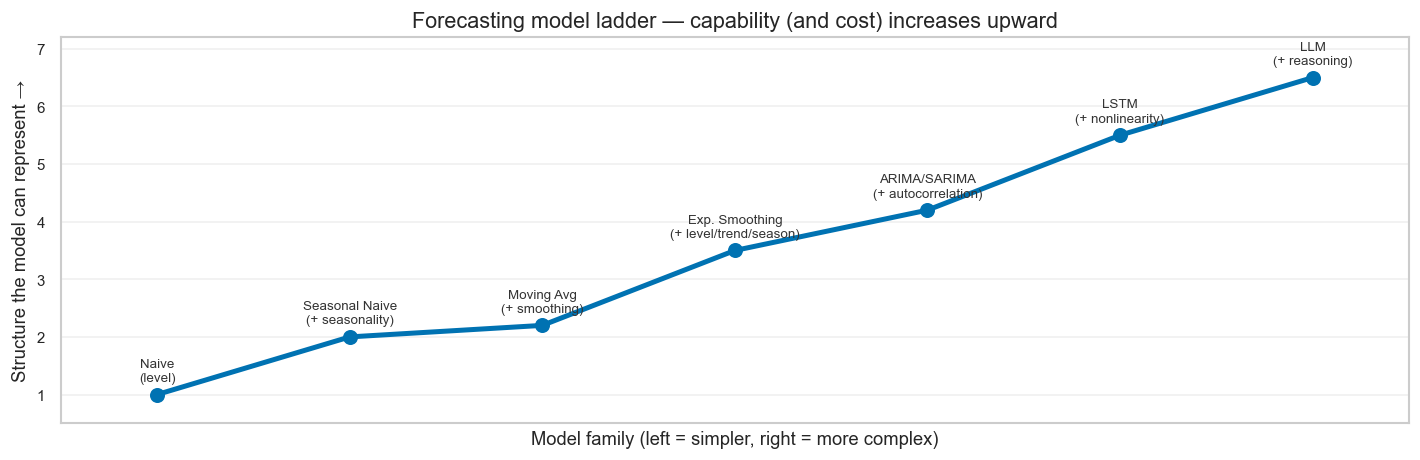

Saved: 11_forecasting_model_ladder.png


In [13]:
# Model ladder as a figure (educational, not a metric plot)
labels = ["Naive\n(level)", "Seasonal Naive\n(+ seasonality)", "Moving Avg\n(+ smoothing)",
          "Exp. Smoothing\n(+ level/trend/season)", "ARIMA/SARIMA\n(+ autocorrelation)", "LSTM\n(+ nonlinearity)", "LLM\n(+ reasoning)"]
complexity = np.arange(len(labels))
capability = [1, 2, 2.2, 3.5, 4.2, 5.5, 6.5]

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(complexity, capability, marker="o", color="#0072B2", lw=3, ms=8)
for i, lab in enumerate(labels):
    ax.text(complexity[i], capability[i]+0.18, lab, ha="center", va="bottom", fontsize=8, color="#333333")
ax.set_xlim(-0.5, len(labels)-0.5)
ax.set_ylim(0.5, 7.2)
ax.set_title("Forecasting model ladder — capability (and cost) increases upward")
ax.set_xlabel("Model family (left = simpler, right = more complex)")
ax.set_ylabel("Structure the model can represent →")
ax.set_xticks([]); ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / "11_forecasting_model_ladder.png", bbox_inches="tight", dpi=150)
plt.show()
print("Saved: 11_forecasting_model_ladder.png")

---

# 12. Business / Inventory Connection

Demand components do not stay academic — they become inventory decisions.

| Component | Operational meaning | If ignored |
|---|---|---|
| **Level** | Typical replenishment need | Systematically wrong order size |
| **Trend** | Persistent growth/decline | Under-forecasting rising demand → stockouts; over-forecasting falling demand → excess |
| **Seasonality** | Predictable weekly peaks | Stockout every Saturday if weekday pattern is ignored |
| **Noise** | Uncertainty | Without safety stock, even an unbiased forecast will stock out ~50% of the time |

```
Demand pattern  →  Forecast  →  Inventory decision  →  Stockout / excess  →  Cost
   (level,
 trend,
 seasonality,
   noise)
```

> Forecasting error has a price. The same MAE can mean different costs depending on *bias* (systematic over/under), *volatility*, and *when* the error occurs (peak vs trough). The inventory simulation (later notebooks) makes this explicit.

**Example:** Store Item Demand with strong Saturday seasonality — a level-only model (Naive, MA) will under-order every Saturday. The bias is visible in the weekly profile and directly explains the inventory risk.

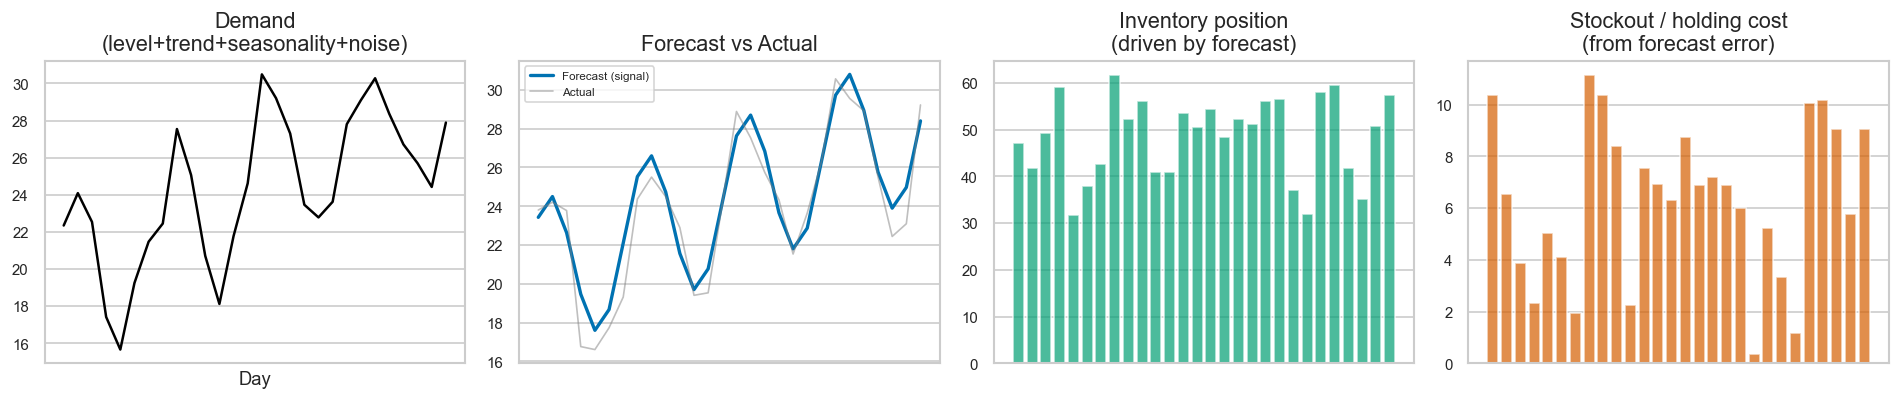

Saved: 12_inventory_connection.png


In [14]:
# Educational schematic: level/trend/seasonality/noise -> forecast -> inventory
# Simple schematic as a figure (not a simulation)
fig, axes = plt.subplots(1, 4, figsize=(16, 3.5))
x = np.arange(1, 29)
# Panel 1: demand with components highlighted
axes[0].plot(x, 20 + 0.3*x + 4*np.sin(2*np.pi*x/7) + rng.normal(0,1.2,size=len(x)), color="black", lw=1.5)
axes[0].set_title("Demand\n(level+trend+seasonality+noise)")
axes[0].set_xlabel("Day")
# Panel 2: forecast
axes[1].plot(x, 20 + 0.3*x + 4*np.sin(2*np.pi*x/7), color="#0072B2", lw=2, label="Forecast (signal)")
axes[1].plot(x, 20 + 0.3*x + 4*np.sin(2*np.pi*x/7) + rng.normal(0,1.2,size=len(x)), color="gray", lw=1, alpha=0.5, label="Actual")
axes[1].set_title("Forecast vs Actual"); axes[1].legend(fontsize=7)
# Panel 3: inventory
axes[2].bar(x, rng.normal(50, 8, size=len(x)), color="#009E73", alpha=0.7)
axes[2].set_title("Inventory position\n(driven by forecast)")
# Panel 4: cost
axes[3].bar(x, np.abs(rng.normal(5, 3, size=len(x))), color="#D55E00", alpha=0.7)
axes[3].set_title("Stockout / holding cost\n(from forecast error)")
for ax in axes: ax.set_xticks([])
plt.tight_layout()
plt.savefig(FIG_DIR / "12_inventory_connection.png", bbox_inches="tight", dpi=150)
plt.show()
print("Saved: 12_inventory_connection.png")

---

# 13. Hand-Worked Example

Two weeks of demand (units):

| Week | Mon | Tue | Wed | Thu | Fri | Sat | Sun |
|---|---:|---:|---:|---:|---:|---:|---:|
| Week 1 | 10 | 12 | 11 | 13 | 15 | 20 | 18 |
| Week 2 | 11 | 13 | 12 | 14 | 16 | 22 | 19 |

**Level:** Both weeks average ~14–15 → level around 14. A 7-day rolling mean would track this.

**Weekly seasonality:** Saturday is highest both weeks (20, 22); Monday lowest (10, 11). Seasonal effect ≈ +6 on Saturday vs Monday baseline.

**Trend:** Week 2 is roughly +1 unit higher per weekday vs Week 1 → gentle upward trend of ~1/7 ≈ 0.14 per day.

**Noise:** Week 1 Wednesday 11 vs Week 2 Wednesday 12 — small irregular variation around the seasonal pattern.

> Even without fitting a model, we can *see* the components. The next notebooks test whether models can *learn* them and whether that improves out-of-sample forecasts.

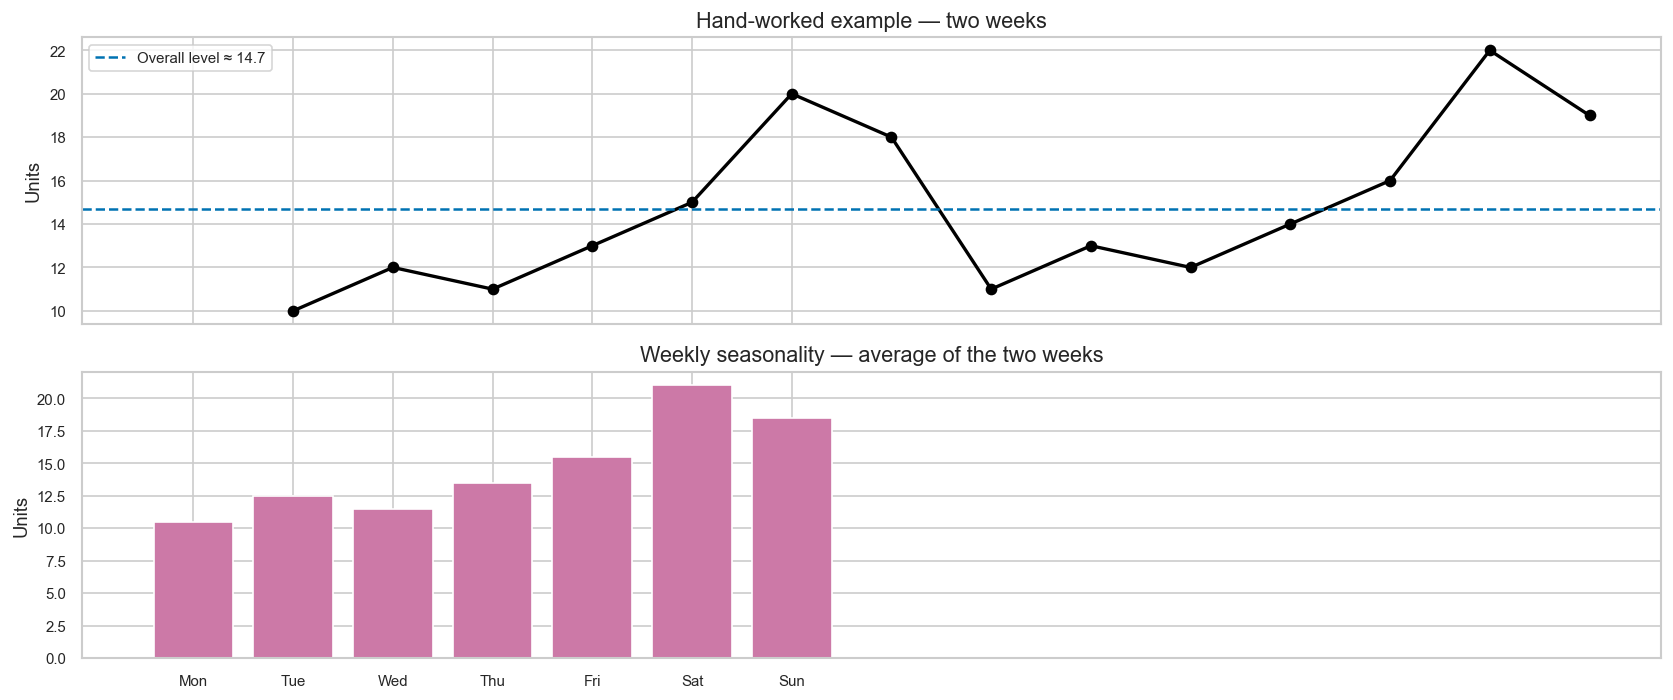

Saved: 13_hand_worked_example.png


In [15]:
# Plot the hand-worked example
week1 = np.array([10,12,11,13,15,20,18], dtype=float)
week2 = np.array([11,13,12,14,16,22,19], dtype=float)
both = np.concatenate([week1, week2])
days = np.arange(1,15)
labels_14 = ["W1 Mon","Tue","Wed","Thu","Fri","Sat","Sun","W2 Mon","Tue","Wed","Thu","Fri","Sat","Sun"]

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
axes[0].plot(days, both, marker="o", color="black", lw=2, ms=6)
axes[0].axhline(both.mean(), color="#0072B2", ls="--", label=f"Overall level ≈ {both.mean():.1f}")
axes[0].set_title("Hand-worked example — two weeks")
axes[0].set_ylabel("Units"); axes[0].legend()
axes[0].set_xticks(days); axes[0].set_xticklabels(labels_14, rotation=25, fontsize=8)

# Weekly profile across the two weeks
weekly_avg = (week1 + week2)/2
axes[1].bar(range(7), weekly_avg, color="#CC79A7", edgecolor="white")
axes[1].set_xticks(range(7)); axes[1].set_xticklabels(["Mon","Tue","Wed","Thu","Fri","Sat","Sun"])
axes[1].set_title("Weekly seasonality — average of the two weeks")
axes[1].set_ylabel("Units")
plt.tight_layout()
plt.savefig(FIG_DIR / "13_hand_worked_example.png", bbox_inches="tight", dpi=150)
plt.show()
print("Saved: 13_hand_worked_example.png")

---

# 14. Common Misunderstandings

| Misreading | Truth |
|---|---|
| "This upward run *is* a trend" | A few points can be noise; trend needs persistence across weeks |
| "This spike *is* seasonality" | One Saturday peak is not seasonality — *repetition* is |
| "Noise means bad data" | Noise is inherent randomness; it calls for uncertainty handling, not data cleaning |
| "High correlation means good forecast" | Autocorrelation can be spurious; only out-of-sample rolling evaluation proves usefulness |
| "Decomposition guarantees better forecasts" | Decomposing describes the past; forecasting requires the structure to *persist* into the future |

> **Research discipline:** Do not assume a more sophisticated model is better *because* it can represent more components. Test it on the frozen rolling evaluation and let the metrics decide.

---

# What This Unlocks Next

- **05b (next):** Now that we know what to look for, we measure what the simplest *actual* models achieve — Naive, Seasonal Naive (weekly repeat), Moving Average (validation-only window).
- **06:** Exponential Smoothing adds explicit level / trend / seasonality states (SES/DES/TES).
- **07 onward:** ARIMA, LSTM, LLM each add a different view of temporal structure — but only where the components justify them.

The ladder is not about complexity for its own sake; it is about *matching model capability to data structure*.

---

## Artifacts produced by this notebook

- Educational figures only, under `07_figures/model_explanations/time_series_components/` (13 figures: `01`–`13`).
- No `06_results/` changes — this notebook is conceptual, not a benchmark.
- No frozen experiment change — same common window, series, horizon, origins, metrics.

In [16]:
import pathlib
figs = sorted((PROJ / "07_figures/model_explanations/time_series_components").glob("*.png"))
print(f"Educational figures saved: {len(figs)}")
for p in figs:
    print(f"  {p.name}  ({p.stat().st_size/1024:.1f} KB)")
print("\nDatasets modified: NO")
print("Frozen experiment modified: NO")
print("Next: 05b_baseline_forecasting.ipynb (actual baseline experiments)")

Educational figures saved: 19
  01_time_series_basics.png  (105.7 KB)
  02_level.png  (105.1 KB)
  03_trend.png  (96.6 KB)
  04_seasonality.png  (96.4 KB)
  04b_weekly_profile.png  (23.9 KB)
  05_noise.png  (127.3 KB)
  06_components_combined.png  (186.5 KB)
  07_additive_vs_multiplicative.png  (140.0 KB)
  08_m5_series_1.png  (124.1 KB)
  08_m5_series_2.png  (138.9 KB)
  08_m5_series_3.png  (88.3 KB)
  08_m5_series_4.png  (114.6 KB)
  09_store_item_high_demand.png  (276.6 KB)
  09_store_item_low_demand.png  (303.4 KB)
  09_store_item_median_demand.png  (279.3 KB)
  10_dataset_structure_comparison.png  (77.3 KB)
  11_forecasting_model_ladder.png  (74.1 KB)
  12_inventory_connection.png  (107.0 KB)
  13_hand_worked_example.png  (79.3 KB)

Datasets modified: NO
Frozen experiment modified: NO
Next: 05b_baseline_forecasting.ipynb (actual baseline experiments)
